In [ ]:
import numpy as np
from scipy.io import loadmat
import keras
import keras.backend as K
from keras.layers import Dense, Activation, LeakyReLU, BatchNormalization
from keras.layers import Conv2D, Conv2DTranspose, Reshape, Flatten
from keras.models import Sequential
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input

%matplotlib inline


In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

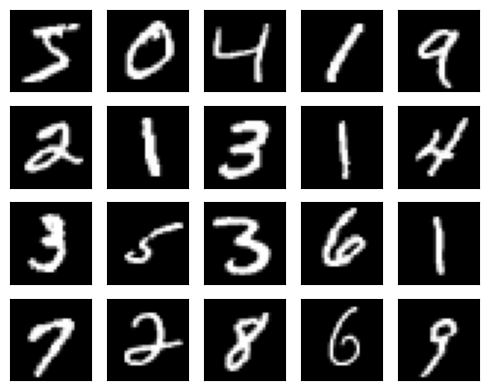

In [ ]:
plt.figure(figsize=(5, 4))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

In [ ]:
def preprocess(x):
    x = x.reshape(-1, 28, 28, 1) # 28,28,1
    x = np.float64(x)
    x = (x / 255 - 0.5) * 2
    x = np.clip(x, -1, 1)
    return x

def deprocess(x):
    x = (x / 2 + 1) * 255
    x = np.clip(x, 0, 255)
    x = np.uint8(x)
    x = x.reshape(28, 28)
    return x

In [ ]:
X_train_real = preprocess(X_train)
X_test_real  = preprocess(X_test)

In [ ]:
def make_generator(input_size, leaky_alpha):
    # generates images in (28,28,1)
    return Sequential([
        Input(shape=(input_size,)),  # ✅ Add Input layer

        # FC 1: 7x7x16
        Dense(784),
        Reshape(target_shape=(7, 7, 16)),
        BatchNormalization(),
        LeakyReLU(negative_slope=leaky_alpha),  # ✅ use negative_slope instead of alpha

        # Conv 1: 14x14x32
        Conv2DTranspose(32, kernel_size=5, strides=2, padding='same'),
        BatchNormalization(),
        LeakyReLU(negative_slope=leaky_alpha),  # ✅ use negative_slope

        # Conv 2: 28x28x1
        Conv2DTranspose(1, kernel_size=5, strides=2, padding='same'),
        Activation('tanh')
    ])

In [ ]:
def make_discriminator(leaky_alpha):
    # classifies images in (28,28,1)
    return Sequential([
        Input(shape=(28, 28, 1)),  # ✅ Add Input layer here

        # Conv 1: 14x14x32
        Conv2D(32, kernel_size=5, strides=2, padding='same'),
        LeakyReLU(negative_slope=leaky_alpha),  # ✅ Use negative_slope

        # Conv 2: 7x7x16
        Conv2D(16, kernel_size=5, strides=2, padding='same'),
        BatchNormalization(),
        LeakyReLU(negative_slope=leaky_alpha),  # ✅ Use negative_slope

        # FC 1
        Flatten(),
        Dense(784),
        BatchNormalization(),
        LeakyReLU(negative_slope=leaky_alpha),  # ✅ Use negative_slope

        # Output
        Dense(1),
        Activation('sigmoid')
    ])

In [ ]:
# beta_1 is the exponential decay rate for the 1st moment estimates in Adam optimizer
def make_DCGAN(sample_size,
               g_learning_rate,
               g_beta_1,
               d_learning_rate,
               d_beta_1,
               leaky_alpha):
    # clear first
    K.clear_session()

    # generator
    generator = make_generator(sample_size, leaky_alpha)

    # discriminator
    discriminator = make_discriminator(leaky_alpha)
    discriminator.compile(optimizer=Adam(learning_rate=d_learning_rate, beta_1=d_beta_1), loss='binary_crossentropy')

    # GAN
    gan = Sequential([generator, discriminator])
    gan.compile(optimizer=Adam(learning_rate=g_learning_rate, beta_1=g_beta_1), loss='binary_crossentropy')

    return gan, generator, discriminator

In [ ]:
def make_latent_samples(n_samples, sample_size):
    #return np.random.uniform(-1, 1, size=(n_samples, sample_size))
    return np.random.normal(loc=0, scale=1, size=(n_samples, sample_size))

In [ ]:
def make_trainable(model, trainable):
    for layer in model.layers:
        layer.trainable = trainable

In [ ]:

def make_labels(size):
    return np.ones([size, 1]), np.zeros([size, 1])

In [ ]:
def show_results(losses):
    labels = ['Classifier', 'Discriminator', 'Generator']
    losses = np.array(losses)

    fig, ax = plt.subplots()
    plt.plot(losses.T[0], label='Discriminator')
    plt.plot(losses.T[1], label='Generator')
    plt.title("Training Losses")
    plt.legend()
    plt.show()


In [ ]:
def show_images(generated_images):
    n_images = len(generated_images)
    rows = 4
    cols = n_images//rows

    plt.figure(figsize=(cols, rows))
    for i in range(n_images):
        img = deprocess(generated_images[i])
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='gray')
        plt.xticks([])
        plt.yticks([])
    plt.tight_layout()
    plt.show()

In [ ]:
def train(
    g_learning_rate,   # learning rate for the generator
    g_beta_1,          # the exponential decay rate for the 1st moment estimates in Adam optimizer
    d_learning_rate,   # learning rate for the discriminator
    d_beta_1,          # the exponential decay rate for the 1st moment estimates in Adam optimizer
    leaky_alpha,
    smooth=0.1,        # label smoothing
    sample_size=100,   # latent sample size (i.e. 100 random numbers)
    epochs=100,
    batch_size=128,    # train batch size
    eval_size=16,      # evaluate size
    show_details=True):

    # labels for the batch size and the test size
    y_train_real, y_train_fake = make_labels(batch_size)
    y_eval_real,  y_eval_fake  = make_labels(eval_size)

    # create a GAN, a generator and a discriminator
    gan, generator, discriminator = make_DCGAN(
        sample_size,
        g_learning_rate,
        g_beta_1,
        d_learning_rate,
        d_beta_1,
        leaky_alpha)
    losses = []
    for e in range(epochs):
        for i in range(len(X_train_real)//batch_size):
            # real MNIST digit images
            X_batch_real = X_train_real[i*batch_size:(i+1)*batch_size]

            # latent samples and the generated digit images
            latent_samples = make_latent_samples(batch_size, sample_size)
            X_batch_fake = generator.predict_on_batch(latent_samples)

            # train the discriminator to detect real and fake images
            make_trainable(discriminator, True)
            discriminator.train_on_batch(X_batch_real, y_train_real * (1 - smooth))
            discriminator.train_on_batch(X_batch_fake, y_train_fake)

            # train the generator via GAN
            make_trainable(discriminator, False)
            gan.train_on_batch(latent_samples, y_train_real)

        # evaluate
        X_eval_real = X_test_real[np.random.choice(len(X_test_real), eval_size, replace=False)]

        latent_samples = make_latent_samples(eval_size, sample_size)
        X_eval_fake = generator.predict_on_batch(latent_samples)

        d_loss  = discriminator.test_on_batch(X_eval_real, y_eval_real)
        d_loss += discriminator.test_on_batch(X_eval_fake, y_eval_fake)
        g_loss  = gan.test_on_batch(latent_samples, y_eval_real) # we want the fake to be realistic!

        losses.append((d_loss, g_loss))

        print("Epoch:{:>3}/{} Discriminator Loss:{:>7.4f} Generator Loss:{:>7.4f}".format(
            e+1, epochs, d_loss, g_loss))

        if show_details and (e+1)%10==0:
            show_images(X_eval_fake)
    if show_details:
        show_results(losses)
    return generator

Epoch:  1/100 Discriminator Loss: 0.7162 Generator Loss: 0.1416
Epoch:  2/100 Discriminator Loss: 0.5579 Generator Loss: 0.0708
Epoch:  3/100 Discriminator Loss: 0.4935 Generator Loss: 0.0472
Epoch:  4/100 Discriminator Loss: 0.4566 Generator Loss: 0.0354
Epoch:  5/100 Discriminator Loss: 0.4327 Generator Loss: 0.0284
Epoch:  6/100 Discriminator Loss: 0.4162 Generator Loss: 0.0237
Epoch:  7/100 Discriminator Loss: 0.4041 Generator Loss: 0.0204
Epoch:  8/100 Discriminator Loss: 0.3962 Generator Loss: 0.0191
Epoch:  9/100 Discriminator Loss: 0.3889 Generator Loss: 0.0171
Epoch: 10/100 Discriminator Loss: 0.3829 Generator Loss: 0.0154


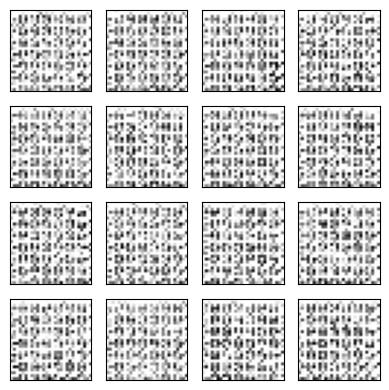

Epoch: 11/100 Discriminator Loss: 0.3780 Generator Loss: 0.0141
Epoch: 12/100 Discriminator Loss: 0.3738 Generator Loss: 0.0130
Epoch: 13/100 Discriminator Loss: 0.3703 Generator Loss: 0.0121
Epoch: 14/100 Discriminator Loss: 0.3672 Generator Loss: 0.0113
Epoch: 15/100 Discriminator Loss: 0.3645 Generator Loss: 0.0108
Epoch: 16/100 Discriminator Loss: 0.3622 Generator Loss: 0.0104
Epoch: 17/100 Discriminator Loss: 0.3601 Generator Loss: 0.0101
Epoch: 18/100 Discriminator Loss: 0.3582 Generator Loss: 0.0099
Epoch: 19/100 Discriminator Loss: 0.3566 Generator Loss: 0.0098
Epoch: 20/100 Discriminator Loss: 0.3551 Generator Loss: 0.0098


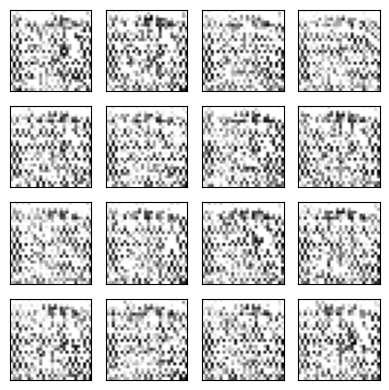

Epoch: 21/100 Discriminator Loss: 0.3539 Generator Loss: 0.0101
Epoch: 22/100 Discriminator Loss: 0.3527 Generator Loss: 0.0102
Epoch: 23/100 Discriminator Loss: 0.3516 Generator Loss: 0.0102
Epoch: 24/100 Discriminator Loss: 0.3506 Generator Loss: 0.0101
Epoch: 25/100 Discriminator Loss: 0.3497 Generator Loss: 0.0100
Epoch: 26/100 Discriminator Loss: 0.3488 Generator Loss: 0.0099
Epoch: 27/100 Discriminator Loss: 0.3480 Generator Loss: 0.0099
Epoch: 28/100 Discriminator Loss: 0.3472 Generator Loss: 0.0099
Epoch: 29/100 Discriminator Loss: 0.3465 Generator Loss: 0.0099
Epoch: 30/100 Discriminator Loss: 0.3459 Generator Loss: 0.0101


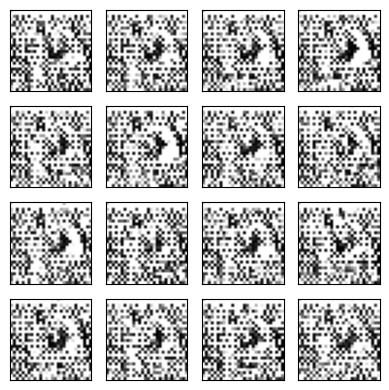

Epoch: 31/100 Discriminator Loss: 0.3453 Generator Loss: 0.0102
Epoch: 32/100 Discriminator Loss: 0.3448 Generator Loss: 0.0102
Epoch: 33/100 Discriminator Loss: 0.3442 Generator Loss: 0.0102
Epoch: 34/100 Discriminator Loss: 0.3438 Generator Loss: 0.0102
Epoch: 35/100 Discriminator Loss: 0.3433 Generator Loss: 0.0102
Epoch: 36/100 Discriminator Loss: 0.3428 Generator Loss: 0.0102
Epoch: 37/100 Discriminator Loss: 0.3424 Generator Loss: 0.0102
Epoch: 38/100 Discriminator Loss: 0.3420 Generator Loss: 0.0101
Epoch: 39/100 Discriminator Loss: 0.3416 Generator Loss: 0.0101
Epoch: 40/100 Discriminator Loss: 0.3412 Generator Loss: 0.0101


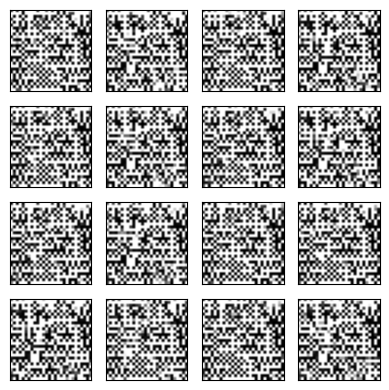

Epoch: 41/100 Discriminator Loss: 0.3408 Generator Loss: 0.0100
Epoch: 42/100 Discriminator Loss: 0.3405 Generator Loss: 0.0101
Epoch: 43/100 Discriminator Loss: 0.3402 Generator Loss: 0.0101
Epoch: 44/100 Discriminator Loss: 0.3398 Generator Loss: 0.0102
Epoch: 45/100 Discriminator Loss: 0.3395 Generator Loss: 0.0102
Epoch: 46/100 Discriminator Loss: 0.3393 Generator Loss: 0.0106
Epoch: 47/100 Discriminator Loss: 0.3390 Generator Loss: 0.0108
Epoch: 48/100 Discriminator Loss: 0.3387 Generator Loss: 0.0109
Epoch: 49/100 Discriminator Loss: 0.3385 Generator Loss: 0.0110
Epoch: 50/100 Discriminator Loss: 0.3382 Generator Loss: 0.0111


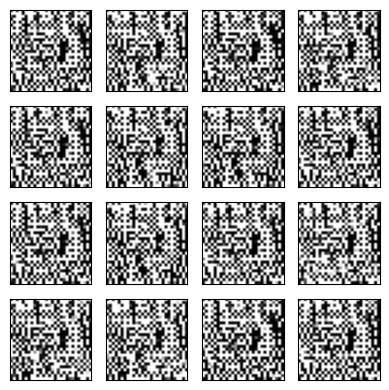

Epoch: 51/100 Discriminator Loss: 0.3380 Generator Loss: 0.0111
Epoch: 52/100 Discriminator Loss: 0.3378 Generator Loss: 0.0113
Epoch: 53/100 Discriminator Loss: 0.3376 Generator Loss: 0.0114
Epoch: 54/100 Discriminator Loss: 0.3374 Generator Loss: 0.0116
Epoch: 55/100 Discriminator Loss: 0.3371 Generator Loss: 0.0118
Epoch: 56/100 Discriminator Loss: 0.3370 Generator Loss: 0.0121
Epoch: 57/100 Discriminator Loss: 0.3368 Generator Loss: 0.0125
Epoch: 58/100 Discriminator Loss: 0.3366 Generator Loss: 0.0130
Epoch: 59/100 Discriminator Loss: 0.3364 Generator Loss: 0.0134
Epoch: 60/100 Discriminator Loss: 0.3362 Generator Loss: 0.0136


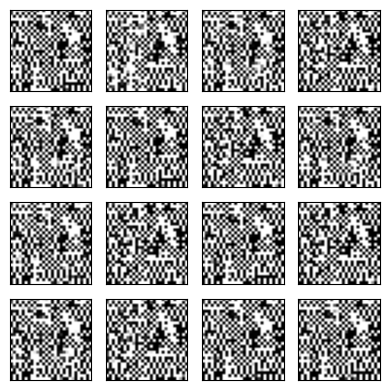

Epoch: 61/100 Discriminator Loss: 0.3361 Generator Loss: 0.0139
Epoch: 62/100 Discriminator Loss: 0.3359 Generator Loss: 0.0142
Epoch: 63/100 Discriminator Loss: 0.3358 Generator Loss: 0.0144
Epoch: 64/100 Discriminator Loss: 0.3356 Generator Loss: 0.0146
Epoch: 65/100 Discriminator Loss: 0.3355 Generator Loss: 0.0148
Epoch: 66/100 Discriminator Loss: 0.3353 Generator Loss: 0.0150
Epoch: 67/100 Discriminator Loss: 0.3352 Generator Loss: 0.0152
Epoch: 68/100 Discriminator Loss: 0.3351 Generator Loss: 0.0154
Epoch: 69/100 Discriminator Loss: 0.3349 Generator Loss: 0.0157
Epoch: 70/100 Discriminator Loss: 0.3348 Generator Loss: 0.0160


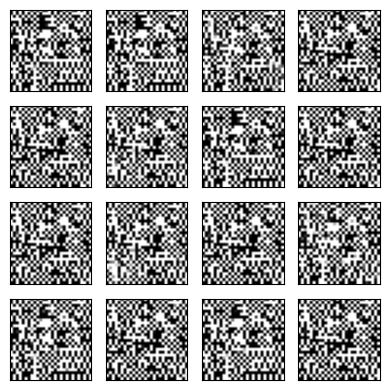

Epoch: 71/100 Discriminator Loss: 0.3347 Generator Loss: 0.0163
Epoch: 72/100 Discriminator Loss: 0.3346 Generator Loss: 0.0166
Epoch: 73/100 Discriminator Loss: 0.3345 Generator Loss: 0.0169
Epoch: 74/100 Discriminator Loss: 0.3343 Generator Loss: 0.0172
Epoch: 75/100 Discriminator Loss: 0.3342 Generator Loss: 0.0176
Epoch: 76/100 Discriminator Loss: 0.3341 Generator Loss: 0.0179
Epoch: 77/100 Discriminator Loss: 0.3340 Generator Loss: 0.0183
Epoch: 78/100 Discriminator Loss: 0.3339 Generator Loss: 0.0186
Epoch: 79/100 Discriminator Loss: 0.3338 Generator Loss: 0.0189
Epoch: 80/100 Discriminator Loss: 0.3337 Generator Loss: 0.0193


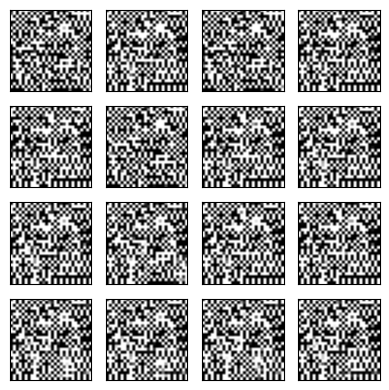

Epoch: 81/100 Discriminator Loss: 0.3336 Generator Loss: 0.0195
Epoch: 82/100 Discriminator Loss: 0.3335 Generator Loss: 0.0198
Epoch: 83/100 Discriminator Loss: 0.3334 Generator Loss: 0.0200
Epoch: 84/100 Discriminator Loss: 0.3334 Generator Loss: 0.0202
Epoch: 85/100 Discriminator Loss: 0.3333 Generator Loss: 0.0205
Epoch: 86/100 Discriminator Loss: 0.3332 Generator Loss: 0.0208
Epoch: 87/100 Discriminator Loss: 0.3331 Generator Loss: 0.0211
Epoch: 88/100 Discriminator Loss: 0.3330 Generator Loss: 0.0214
Epoch: 89/100 Discriminator Loss: 0.3330 Generator Loss: 0.0217
Epoch: 90/100 Discriminator Loss: 0.3329 Generator Loss: 0.0219


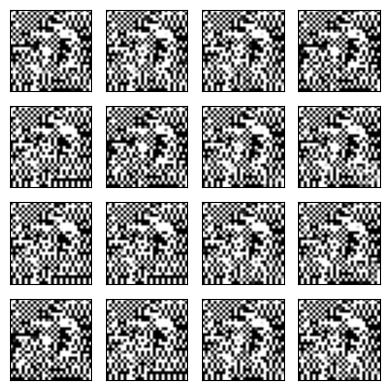

Epoch: 91/100 Discriminator Loss: 0.3328 Generator Loss: 0.0222
Epoch: 92/100 Discriminator Loss: 0.3327 Generator Loss: 0.0225
Epoch: 93/100 Discriminator Loss: 0.3327 Generator Loss: 0.0227
Epoch: 94/100 Discriminator Loss: 0.3326 Generator Loss: 0.0230
Epoch: 95/100 Discriminator Loss: 0.3325 Generator Loss: 0.0231
Epoch: 96/100 Discriminator Loss: 0.3325 Generator Loss: 0.0233
Epoch: 97/100 Discriminator Loss: 0.3324 Generator Loss: 0.0234
Epoch: 98/100 Discriminator Loss: 0.3323 Generator Loss: 0.0235
Epoch: 99/100 Discriminator Loss: 0.3323 Generator Loss: 0.0236
Epoch:100/100 Discriminator Loss: 0.3322 Generator Loss: 0.0237


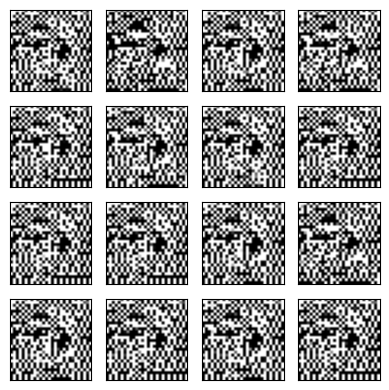

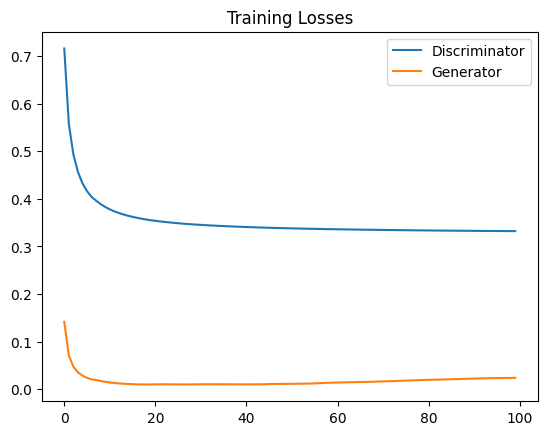

In [ ]:
train(g_learning_rate=0.0001, g_beta_1=0.9, d_learning_rate=0.001, d_beta_1=0.9, leaky_alpha=0.1);

In [ ]:
train(g_learning_rate=0.0001, g_beta_1=0.9, d_learning_rate=0.001, d_beta_1=0.9, leaky_alpha=0.2);

KeyboardInterrupt: 